In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('dados_cerveja_nota.xlsx')

In [4]:
df

,id,cerveja,nota
0,1,1,0.75
1,2,1,3.00
2,3,2,1.75
3,4,3,1.75
4,5,4,4.20
5,6,4,6.50
6,7,5,2.90
7,8,6,6.20
8,9,6,7.00
9,10,7,6.20


In [7]:
## Criar Classe "Passou"

df['Aprovado'] = (df['nota'] > 5).astype(int)
df

,id,cerveja,nota,Aprovado
0,1,1,0.75,0
1,2,1,3.00,0
2,3,2,1.75,0
3,4,3,1.75,0
4,5,4,4.20,0
5,6,4,6.50,1
6,7,5,2.90,0
7,8,6,6.20,1
8,9,6,7.00,1
9,10,7,6.20,1


Text(0, 0.5, 'Aprovados')

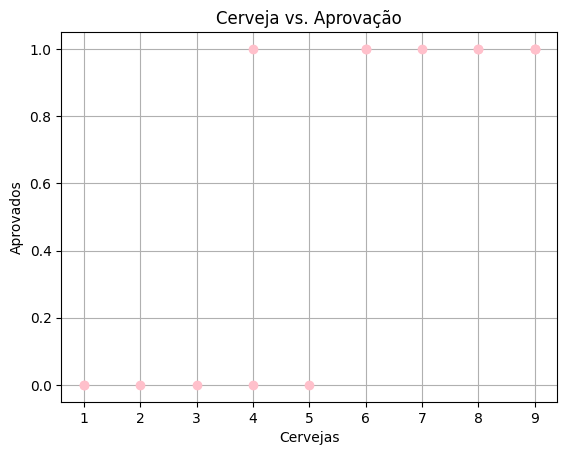

In [11]:
import matplotlib.pyplot as plt

# Plotar

plt.plot(df['cerveja'], df['Aprovado'], 'o', color='pink')
plt.grid(True)
plt.title('Cerveja vs. Aprovação')
plt.xlabel('Cervejas')
plt.ylabel('Aprovados')

# **Regressão Logística**



In [14]:
# Regressão Logística
from sklearn import linear_model
reg = linear_model.LogisticRegression(penalty=None,
                                      fit_intercept=True)

X = df[['cerveja']]
y = df['Aprovado']


reg.fit(X, y)

LogisticRegression(penalty=None)

In [20]:
predict_ = reg.predict(df[['cerveja']].drop_duplicates())

In [52]:
predict_proba = reg.predict_proba(df[['cerveja']].drop_duplicates())[:,1]

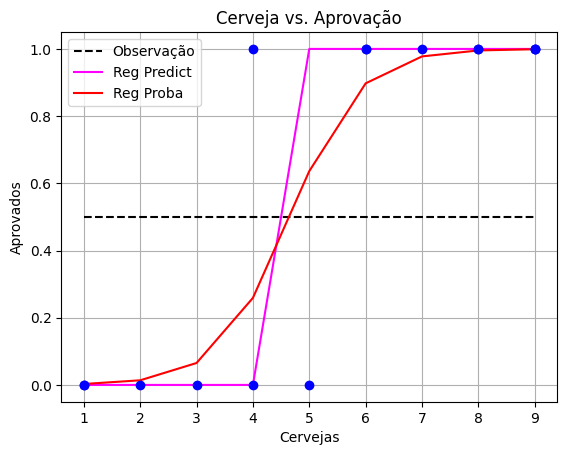

In [53]:
plt.hlines(0.5, xmin=1, xmax=9, linestyles='--', color='black')
# Predição da Regressão Logística
plt.plot(df['cerveja'].drop_duplicates(), predict_, color='magenta')
# Probalididade
plt.plot(df['cerveja'].drop_duplicates(), predict_proba, color='red')
# Dados
plt.plot(df['cerveja'], df['Aprovado'], 'o', color='blue')
plt.grid(True)
plt.title('Cerveja vs. Aprovação')
plt.xlabel('Cervejas')
plt.ylabel('Aprovados')


plt.legend(['Observação','Reg Predict','Reg Proba'])

# **Árvore**

In [29]:
from sklearn import tree

In [31]:
arvore_full = tree.DecisionTreeClassifier(random_state=42)
arvore_full.fit(X, y)

DecisionTreeClassifier(random_state=42)

In [32]:
arvore_predict = arvore_full.predict(df[['cerveja']].drop_duplicates())

In [37]:
arvore_predict_prob = arvore_full.predict_proba(df[['cerveja']].drop_duplicates())[:,1]

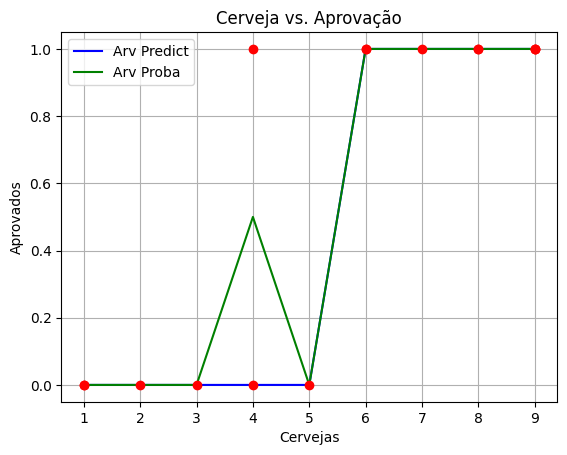

In [39]:
plt.plot(df['cerveja'].drop_duplicates(), arvore_predict, color='blue')
# Probalididade
plt.plot(df['cerveja'].drop_duplicates(), arvore_predict_prob, color='green')
# Dados
plt.plot(df['cerveja'], df['Aprovado'], 'o', color='red')
plt.grid(True)
plt.title('Cerveja vs. Aprovação')
plt.xlabel('Cervejas')
plt.ylabel('Aprovados')


plt.legend(['Arv Predict','Arv Proba'])

In [41]:
arvore_full_d2 = tree.DecisionTreeClassifier(random_state=42, max_depth=2)
arvore_full_d2.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

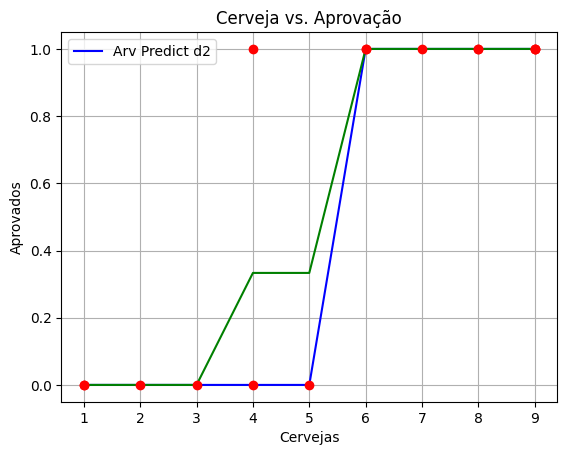

In [43]:
arvore_predictd2 = arvore_full_d2.predict(df[['cerveja']].drop_duplicates())
arvore_predict_probd2 = arvore_full_d2.predict_proba(df[['cerveja']].drop_duplicates())[:,1]
plt.plot(df['cerveja'].drop_duplicates(), arvore_predictd2, color='blue')
plt.plot(df['cerveja'].drop_duplicates(), arvore_predict_probd2, color='green')
# Dados
plt.plot(df['cerveja'], df['Aprovado'], 'o', color='red')
plt.grid(True)
plt.title('Cerveja vs. Aprovação')
plt.xlabel('Cervejas')
plt.ylabel('Aprovados')


plt.legend(['Arv Predict d2'])

# **Naive Bayes**

In [44]:
from sklearn import naive_bayes

In [45]:
nb = naive_bayes.GaussianNB()
nb.fit(X, y)

GaussianNB()

In [50]:
nb_predict = nb.predict(df[['cerveja']].drop_duplicates())
nb_predict_proba = nb.predict_proba(df[['cerveja']].drop_duplicates())[:,1]

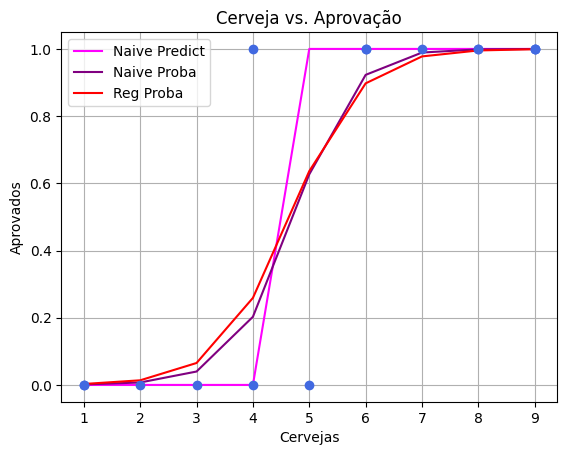

In [56]:
plt.plot(df['cerveja'].drop_duplicates(), nb_predict, color='magenta')
plt.plot(df['cerveja'].drop_duplicates(), nb_predict_proba, color='purple')

plt.plot(df['cerveja'].drop_duplicates(), predict_proba, color='red')
# Dados
plt.plot(df['cerveja'], df['Aprovado'], 'o', color='royalblue')
plt.grid(True)
plt.title('Cerveja vs. Aprovação')
plt.xlabel('Cervejas')
plt.ylabel('Aprovados')

plt.legend(['Naive Predict','Naive Proba','Reg Proba'])
